In [ ]:
CSV_PATH     = "Location1.csv"    # Path to the CSV file
DATETIME_COL = None      
TARGET_COL   = None      
FREQ         = None      
TIMESTEPS    = 24        # TCN context window 
N_SPLITS     = 5         # TimeSeries CV splits (expanding window)
TEST_SIZE    = 168       # validation size per split

SARIMAX_ORDER = (1, 0, 1)    # ARIMA parameters
SARIMAX_D     = 0            # integrated order
SARIMAX_SEASONAL = None      # Seasonality for the SARIMA

# Threshold to decide "nonlinear" features
NONLIN_DELTA_R2 = 0.02

# Amount of Random seeds
RANDOM_STATE = 42


# Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# TensorFlow  for the TCN
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Add, Activation, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Import successful")

Import successful


In [ ]:
# Functions 

def print_metrics(y_true, y_pred, title=""):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    if title:
        print(f"--- {title} ---")
    print(f"MAE : {mae:.4f}\nMSE : {mse:.4f}\nRMSE: {rmse:.4f}\nR^2 : {r2:.4f}\n")

def build_lag_frame(x_col: np.ndarray, nlags: int = 3) -> np.ndarray:
    """Create [t, t-1, ..., t-nlags] columns from a 1D series. Initial rows with NaNs will be dropped downstream."""
    T = len(x_col)
    mats = [x_col]
    for L in range(1, nlags+1):
        lag = np.full(T, np.nan)
        lag[L:] = x_col[:-L]
        mats.append(lag)
    return np.column_stack(mats)

def make_sequences(X, y, timesteps):
    """Turn 2D X(T,F) and y(T,) into sequences (T-timesteps, timesteps, F) and aligned y."""
    X = np.asarray(X); y = np.asarray(y)
    seq_X, seq_y = [], []
    for t in range(timesteps, len(X)):
        seq_X.append(X[t - timesteps:t])
        seq_y.append(y[t])
    return np.array(seq_X), np.array(seq_y)

def build_tcn(timesteps, n_features, filters=64, dropout=0.2, dilations=(1, 2, 4, 8)):
    """Residual TCN for 1-step regression."""
    inp = Input(shape=(timesteps, n_features))
    x = inp
    for d in dilations:
        y = Conv1D(filters=filters, kernel_size=3, padding='causal', dilation_rate=d, activation='relu')(x)
        y = Dropout(dropout)(y)
        y = Conv1D(filters=filters, kernel_size=3, padding='causal', dilation_rate=d, activation='relu')(y)
        if x.shape[-1] != y.shape[-1]:
            x = Conv1D(filters=filters, kernel_size=1, padding='same')(x)
        x = Add()([x, y])
        x = Activation('relu')(x)
    x = GlobalAveragePooling1D()(x)
    out = Dense(1)(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mse')
    return model

def expanding_time_series_folds(n_samples, n_splits=5, test_size=168, min_train_size=24):
    """
    Generator that yields (train_idx, val_idx) for expanding-window TS CV.
    Ensures each train fold has at least min_train_size points.
    """
    total_needed = n_splits * test_size + min_train_size
    if total_needed > n_samples:
        # reduce n_splits if necessary
        n_splits = max(1, (n_samples - min_train_size) // test_size)
    for k in range(1, n_splits + 1):
        val_end = n_samples - (n_splits - k) * test_size
        val_start = val_end - test_size
        train_end = val_start
        if train_end < min_train_size:
            continue
        train_idx = np.arange(0, train_end)
        val_idx   = np.arange(val_start, val_end)
        yield train_idx, val_idx


In [ ]:
# Load and preprocess data

assert os.path.exists(CSV_PATH), f"CSV not found at: {CSV_PATH}"
df_raw = pd.read_csv(CSV_PATH)

# Try to find a datetime column if not provided
if DATETIME_COL is None:
    candidate_dt = None
    for col in df_raw.columns:
        try:
            pd.to_datetime(df_raw[col])
            candidate_dt = col; break
        except Exception:
            continue
    DATETIME_COL = candidate_dt

if DATETIME_COL is not None:
    df_raw[DATETIME_COL] = pd.to_datetime(df_raw[DATETIME_COL], errors='coerce')
    df = df_raw.dropna(subset=[DATETIME_COL]).copy()
    df = df.sort_values(DATETIME_COL).set_index(DATETIME_COL)
    if FREQ:
        df = df.asfreq(FREQ)
else:
    # If No datetime column, just keep row order
    df = df_raw.copy()
    df.index.name = "index"

# Keep only numeric columns for modeling
num_df = df.select_dtypes(include=[np.number]).copy()
assert num_df.shape[1] >= 2, "Need at least 2 numeric columns (target + ≥1 feature)."

# Choose target column if not provided: default to the LAST numeric column
if TARGET_COL is None or TARGET_COL not in num_df.columns:
    TARGET_COL = num_df.columns[-1]
print(f"Using TARGET_COL = '{TARGET_COL}'")

# Features = all other numeric columns
feature_cols = [c for c in num_df.columns if c != TARGET_COL]
X_all = num_df[feature_cols].values
y_all = num_df[TARGET_COL].values
index_all = num_df.index

# Cleaning
X_all = pd.DataFrame(X_all, index=index_all, columns=feature_cols).interpolate(limit_direction='both').values
y_all = pd.Series(y_all, index=index_all).interpolate(limit_direction='both').values

T = len(y_all)
F = len(feature_cols)
print(f"Data shape: T={T}, Features={F}")


Using TARGET_COL = 'Power'
Data shape: T=43800, Features=8


In [ ]:
# SARIMAX OOF baseline (with exogenous features)

y_lin_oof = np.full(T, np.nan, dtype=float)

folds = list(expanding_time_series_folds(T, n_splits=N_SPLITS, test_size=TEST_SIZE, min_train_size=TIMESTEPS))
print(f"Total CV folds: {len(folds)}")

for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
    y_tr, y_va = y_all[train_idx], y_all[val_idx]
    X_tr, X_va = X_all[train_idx], X_all[val_idx]

    # Fit SARIMAX; keep it modest for stability
    try:
        if SARIMAX_SEASONAL is not None:
            model = SARIMAX(endog=y_tr, exog=X_tr, order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEASONAL,
                            enforce_stationarity=False, enforce_invertibility=False)
        else:
            model = SARIMAX(endog=y_tr, exog=X_tr, order=SARIMAX_ORDER,
                            enforce_stationarity=False, enforce_invertibility=False)
        res = model.fit(disp=False)
        y_pred = res.predict(start=val_idx[0], end=val_idx[-1], exog=X_va)
    except Exception as e:
        # Fallback: simple linear regression baseline
        lr = LinearRegression().fit(X_tr, y_tr)
        y_pred = lr.predict(X_va)
        print(f"[Fold {fold_id}] SARIMAX failed -> fallback LinearRegression. Reason: {str(e)[:80]}")

    y_lin_oof[val_idx] = y_pred
    print(f"[Fold {fold_id}] SARIMAX OOF filled: {len(val_idx)}")

# Residuals
residuals_oof = y_all - y_lin_oof

# Remove leading folds that might be NaN if SARIMAX couldn't produce predictions
mask_lin = np.isfinite(y_lin_oof) & np.isfinite(y_all)
print_metrics(y_all[mask_lin], y_lin_oof[mask_lin], title="SARIMAX OOF baseline")


Total CV folds: 5
[Fold 1] SARIMAX OOF filled: 168
[Fold 2] SARIMAX OOF filled: 168
[Fold 3] SARIMAX OOF filled: 168
[Fold 4] SARIMAX OOF filled: 168
[Fold 5] SARIMAX OOF filled: 168
--- SARIMAX OOF baseline ---
MAE : 0.2452
MSE : 0.0771
RMSE: 0.2776
R^2 : 0.1485



In [ ]:
# Nonlinearity screening (per-feature vs residuals)

def oof_r2_single_feature(residuals, feature_vec, nlags=3, alpha=1.0,
                          rf_conf=dict(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)):
    """
    Build lagged single-feature design and compute OOF R^2 for Ridge vs RandomForest
    predicting residuals, using the SAME CV folds.
    """
    Xlags = build_lag_frame(feature_vec, nlags=nlags)           # (T, nlags+1)
    
    # Keep valid rows (all lags present) and finite residuals
    
    mask = np.all(np.isfinite(Xlags), axis=1) & np.isfinite(residuals)
    Xlags = Xlags[mask]; r = residuals[mask]
    if len(r) < 50:
        return np.nan, np.nan

    idx_all = np.where(mask)[0]
    lr_preds = np.full_like(r, np.nan, dtype=float)
    rf_preds = np.full_like(r, np.nan, dtype=float)

    for train_idx, val_idx in folds:
        tr_mask = np.isin(idx_all, train_idx)
        va_mask = np.isin(idx_all, val_idx)
        if not np.any(tr_mask) or not np.any(va_mask):
            continue

        X_tr, y_tr = Xlags[tr_mask], r[tr_mask]
        X_va, y_va = Xlags[va_mask], r[va_mask]

        # Linear model with standardization
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr); X_va_s = scaler.transform(X_va)
        lr = Ridge(alpha=alpha).fit(X_tr_s, y_tr)
        lr_preds[va_mask] = lr.predict(X_va_s)

        # Nonlinear model
        rf = RandomForestRegressor(**rf_conf).fit(X_tr, y_tr)
        rf_preds[va_mask] = rf.predict(X_va)

    ok_lr = np.isfinite(lr_preds)
    ok_rf = np.isfinite(rf_preds)
    r2_lr = r2_score(r[ok_lr], lr_preds[ok_lr]) if ok_lr.any() else np.nan
    r2_rf = r2_score(r[ok_rf], rf_preds[ok_rf]) if ok_rf.any() else np.nan
    return r2_lr, r2_rf

screen_rows = []
for j, feat in enumerate(feature_cols):
    r2_lin, r2_rf = oof_r2_single_feature(residuals_oof, X_all[:, j], nlags=3)
    delta = (r2_rf - r2_lin) if (np.isfinite(r2_lin) and np.isfinite(r2_rf)) else np.nan
    screen_rows.append((feat, r2_lin, r2_rf, delta))
    print(f"{feat:>25s} | R2_lin={r2_lin:.3f} | R2_RF={r2_rf:.3f} | Δ={delta if np.isfinite(delta) else np.nan}")

screen_df = pd.DataFrame(screen_rows, columns=["feature", "r2_linear", "r2_nonlinear", "delta"]).sort_values("delta", ascending=False)
nonlinear_feats = screen_df[(screen_df["delta"] > NONLIN_DELTA_R2) & (screen_df["r2_nonlinear"] > 0)]["feature"].tolist()
linear_feats = [f for f in feature_cols if f not in nonlinear_feats]
print("\nSelected NONLINEAR features:", nonlinear_feats)
print("Remaining LINEAR features:", linear_feats)


           temperature_2m | R2_lin=-0.257 | R2_RF=-0.209 | Δ=0.04790841867082718
      relativehumidity_2m | R2_lin=-0.197 | R2_RF=-0.349 | Δ=-0.1515268470617861
              dewpoint_2m | R2_lin=-0.523 | R2_RF=-0.369 | Δ=0.15484540516198875
            windspeed_10m | R2_lin=0.008 | R2_RF=0.388 | Δ=0.3803141511352178
           windspeed_100m | R2_lin=0.020 | R2_RF=0.373 | Δ=0.3524591584114126
        winddirection_10m | R2_lin=-0.103 | R2_RF=-0.191 | Δ=-0.08784910703565951
       winddirection_100m | R2_lin=-0.101 | R2_RF=-0.171 | Δ=-0.07007739598786777
            windgusts_10m | R2_lin=-0.017 | R2_RF=0.366 | Δ=0.3826819695261854

Selected NONLINEAR features: ['windgusts_10m', 'windspeed_10m', 'windspeed_100m']
Remaining LINEAR features: ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'winddirection_10m', 'winddirection_100m']


In [ ]:
# TCN on residuals (only nonlinear features), OOF

y_hybrid_oof = np.full(T, np.nan, dtype=float)
rhat_oof = np.full(T, np.nan, dtype=float)

if len(nonlinear_feats) == 0:
    print("No nonlinear features identified → Skipping TCN; hybrid == SARIMAX.")
    y_hybrid_oof = y_lin_oof.copy()
else:
    nl_idx = [feature_cols.index(f) for f in nonlinear_feats]
    X_nl = X_all[:, nl_idx]

    for fold_id, (train_idx, val_idx) in enumerate(folds, start=1):
        if len(train_idx) < TIMESTEPS:
            print(f"[Fold {fold_id}] skipped: train_len={len(train_idx)} < TIMESTEPS={TIMESTEPS}")
            continue

        # Training Residuals
        r_tr = residuals_oof[train_idx]

        # Scale features (fit on train), scale residual target
        x_scaler = StandardScaler().fit(X_nl[train_idx])
        r_scaler = StandardScaler().fit(r_tr.reshape(-1, 1))

        X_tr_scaled = x_scaler.transform(X_nl[train_idx])

        # Build validation input with full context
        tail_len = TIMESTEPS
        X_val_input = np.concatenate([X_nl[train_idx[-tail_len:]], X_nl[val_idx]], axis=0)
        X_val_input_scaled = x_scaler.transform(X_val_input)

        # Sequencing
        X_tr_seq, r_tr_seq = make_sequences(X_tr_scaled, r_scaler.transform(r_tr.reshape(-1,1)).ravel(), TIMESTEPS)
        X_val_seq, _ = make_sequences(X_val_input_scaled, np.zeros(len(X_val_input_scaled)), TIMESTEPS)

        # Expect one sequence per validation point
        if X_val_seq.shape[0] != len(val_idx):
            raise ValueError(f"[Fold {fold_id}] TCN val sequences mismatch: got {X_val_seq.shape[0]} vs {len(val_idx)}")

        # Build + train TCN on training sequences
        
        tcn = build_tcn(TIMESTEPS, X_tr_seq.shape[-1], filters=64, dropout=0.2, dilations=(1,2,4,8))
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-5)
        ]
        tcn.fit(X_tr_seq, r_tr_seq, epochs=100, batch_size=32, validation_split=0.1, callbacks=callbacks, verbose=0)

        # Predict residuals on val, inverse-scale
        rhat_val_scaled = tcn.predict(X_val_seq, verbose=0).reshape(-1, 1)
        rhat_val = r_scaler.inverse_transform(rhat_val_scaled).ravel()

        # Assign OOF predictions and hybrid
        rhat_oof[val_idx] = rhat_val
        y_hybrid_oof[val_idx] = y_lin_oof[val_idx] + rhat_val
        print(f"[Fold {fold_id}] TCN filled {len(rhat_val)} residuals using {len(nonlinear_feats)} nonlinear features.")

# if some early folds were skipped, keep SARIMAX where hybrid is NaN
fallback_mask = ~np.isfinite(y_hybrid_oof)
y_hybrid_oof[fallback_mask] = y_lin_oof[fallback_mask]

mask_eval = np.isfinite(y_hybrid_oof) & np.isfinite(y_lin_oof) & np.isfinite(y_all)
print_metrics(y_all[mask_eval], y_lin_oof[mask_eval],    title="Level-1: SARIMAX (OOF)")
print_metrics(y_all[mask_eval], y_hybrid_oof[mask_eval], title="Level-1: Hybrid (Selective TCN OOF)")



[Fold 1] TCN filled 168 residuals using 3 nonlinear features.
[Fold 2] TCN filled 168 residuals using 3 nonlinear features.
[Fold 3] TCN filled 168 residuals using 3 nonlinear features.
[Fold 4] TCN filled 168 residuals using 3 nonlinear features.
[Fold 5] TCN filled 168 residuals using 3 nonlinear features.
--- Level-1: SARIMAX (OOF) ---
MAE : 0.2452
MSE : 0.0771
RMSE: 0.2776
R^2 : 0.1485

--- Level-1: Hybrid (Selective TCN OOF) ---
MAE : 0.2452
MSE : 0.0771
RMSE: 0.2776
R^2 : 0.1485



In [ ]:
# Blender: RandomForest with TRUE OOF

y_naive = np.roll(y_all, 1); y_naive[0] = y_naive[1]

mask_blend = np.isfinite(y_hybrid_oof) & np.isfinite(y_lin_oof) & np.isfinite(y_naive)
Z_all = np.column_stack([y_lin_oof[mask_blend], y_hybrid_oof[mask_blend], y_naive[mask_blend]])
y_btarget = y_all[mask_blend]
idx_all = np.where(mask_blend)[0]

y_blend_oof = np.full_like(y_btarget, np.nan, dtype=float)

for fold_id, (tr_idx, va_idx) in enumerate(folds, start=1):
    tr_mask = np.isin(idx_all, tr_idx)
    va_mask = np.isin(idx_all, va_idx)
    if not np.any(tr_mask) or not np.any(va_mask):
        continue

    Z_tr, y_tr = Z_all[tr_mask], y_btarget[tr_mask]
    Z_va       = Z_all[va_mask]

    blender = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
    blender.fit(Z_tr, y_tr)
    y_blend_oof[va_mask] = blender.predict(Z_va)
    print(f"[Blender] Fold {fold_id}: trained {Z_tr.shape[0]}, predicted {Z_va.shape[0]}.")

# Blender evaluation: guard against NaNs (rows never in a val fold) 
mask_b = np.isfinite(y_blend_oof)
covered = int(mask_b.sum())
total   = len(y_blend_oof)
print(f"Blender OOF coverage: {covered}/{total}")

if covered == 0:
    print("No blender OOF rows available — adjust N_SPLITS/TEST_SIZE or proceed with final-fit only.")
else:
    y_true_b  = y_btarget[mask_b]
    y_sar_b   = Z_all[mask_b, 0]   # SARIMAX (mask-matched)
    y_hyb_b   = Z_all[mask_b, 1]   # Hybrid  (mask-matched)
    y_blend_b = y_blend_oof[mask_b]

    print_metrics(y_true_b, y_sar_b,   title="Level-1: SARIMAX (mask-matched)")
    print_metrics(y_true_b, y_hyb_b,   title="Level-1: Hybrid (mask-matched)")
    print_metrics(y_true_b, y_blend_b, title="Level-2: RF Blender (true OOF)")

# Fit blender on all available rows for later inference
blender_final = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
blender_final.fit(Z_all, y_btarget)


[Blender] Fold 2: trained 168, predicted 168.
[Blender] Fold 3: trained 336, predicted 168.
[Blender] Fold 4: trained 504, predicted 168.
[Blender] Fold 5: trained 672, predicted 168.
Blender OOF coverage: 672/840
--- Level-1: SARIMAX (mask-matched) ---
MAE : 0.2467
MSE : 0.0775
RMSE: 0.2784
R^2 : 0.0903

--- Level-1: Hybrid (mask-matched) ---
MAE : 0.2467
MSE : 0.0775
RMSE: 0.2784
R^2 : 0.0903

--- Level-2: RF Blender (true OOF) ---
MAE : 0.0374
MSE : 0.0025
RMSE: 0.0505
R^2 : 0.9701



,n_estimators,400
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


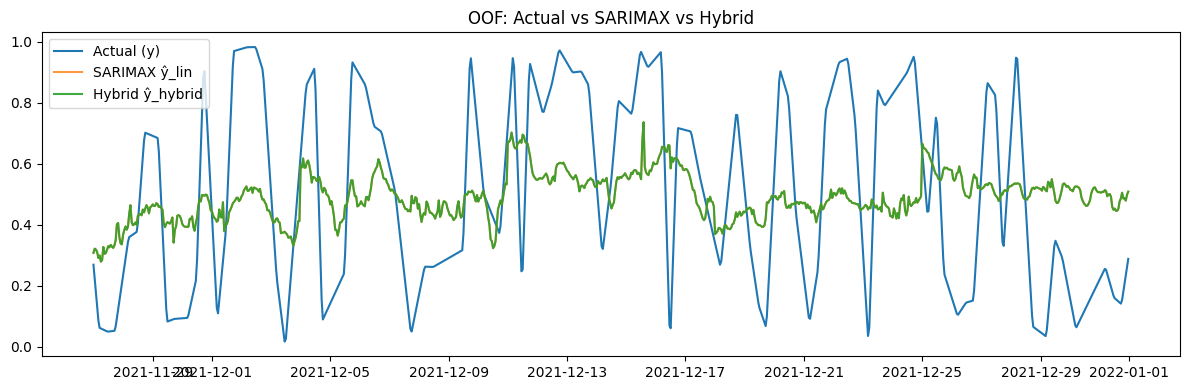

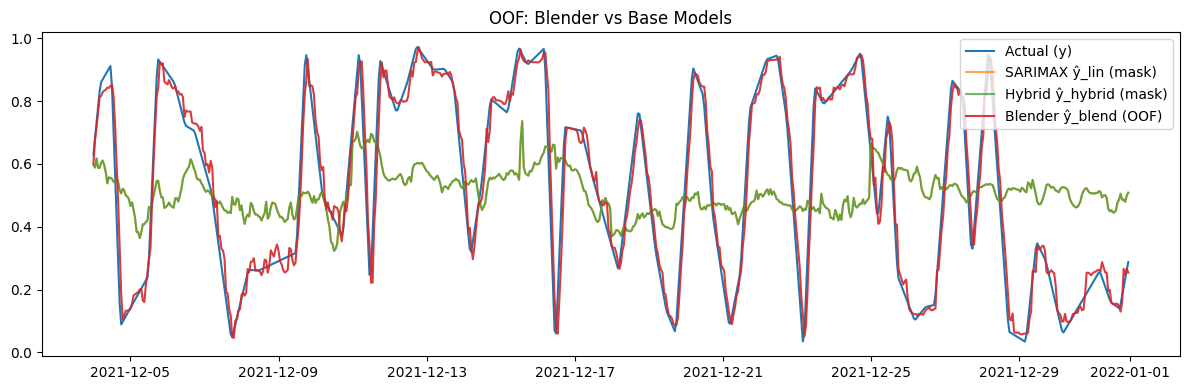

Done.


In [ ]:
# Quick plots

plt.figure(figsize=(12,4))
plt.plot(index_all[mask_eval], y_all[mask_eval], label='Actual (y)')
plt.plot(index_all[mask_eval], y_lin_oof[mask_eval], label='SARIMAX ŷ_lin', alpha=0.8)
plt.plot(index_all[mask_eval], y_hybrid_oof[mask_eval], label='Hybrid ŷ_hybrid', alpha=0.9)
plt.title('OOF: Actual vs SARIMAX vs Hybrid')
plt.legend(); plt.tight_layout(); plt.show()

if np.isfinite(y_blend_oof).any():
    # Align blender OOF timeline
    idx_b = index_all[mask_blend][np.isfinite(y_blend_oof)]
    plt.figure(figsize=(12,4))
    plt.plot(idx_b, y_btarget[np.isfinite(y_blend_oof)], label='Actual (y)')
    plt.plot(idx_b, Z_all[np.isfinite(y_blend_oof),0], label='SARIMAX ŷ_lin (mask)', alpha=0.7)
    plt.plot(idx_b, Z_all[np.isfinite(y_blend_oof),1], label='Hybrid ŷ_hybrid (mask)', alpha=0.7)
    plt.plot(idx_b, y_blend_oof[np.isfinite(y_blend_oof)], label='Blender ŷ_blend (OOF)', alpha=0.9)
    plt.title('OOF: Blender vs Base Models')
    plt.legend(); plt.tight_layout(); plt.show()

print("Done.")


=== Hold-out Test (168 points) ===
--- Test: SARIMAX ---
MAE : 0.2834
MSE : 0.0965
RMSE: 0.3106
R^2 : -0.5472

--- Test: Hybrid (Selective TCN) ---
MAE : 0.2799
MSE : 0.0946
RMSE: 0.3076
R^2 : -0.5180

--- Test: RF Blender ---
MAE : 0.0353
MSE : 0.0021
RMSE: 0.0462
R^2 : 0.9658



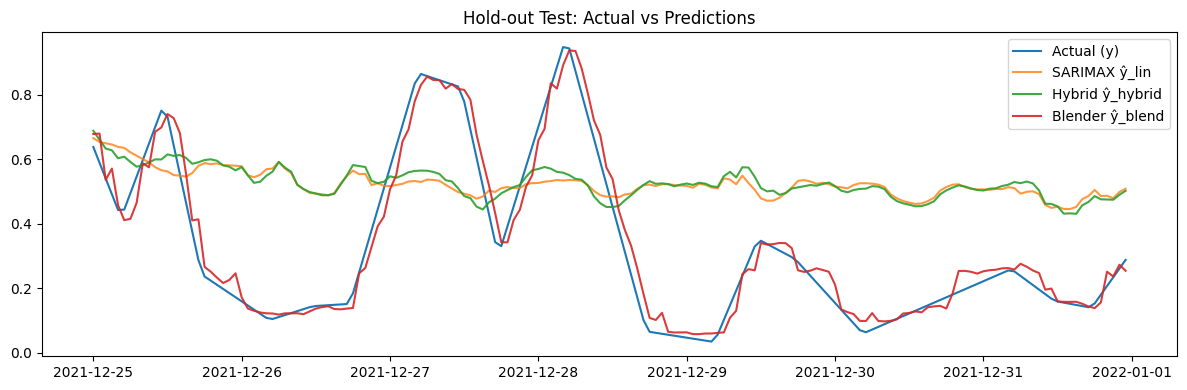

In [ ]:
# Hold-out Test Evaluation (no leakage)

TEST_HORIZON = 168  # last 7 days for test

test_start = max(0, T - TEST_HORIZON)
train_idx_test = np.arange(0, test_start)
test_idx = np.arange(test_start, T)

X_tr_full = X_all[train_idx_test]
y_tr_full = y_all[train_idx_test]
X_te = X_all[test_idx]
y_te = y_all[test_idx]

# SARIMAX: train on train, forecast test
try:
    if SARIMAX_SEASONAL is not None:
        sar_tr = SARIMAX(y_tr_full, exog=X_tr_full, order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEASONAL,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    else:
        sar_tr = SARIMAX(y_tr_full, exog=X_tr_full, order=SARIMAX_ORDER,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    y_lin_test = sar_tr.predict(start=len(y_tr_full), end=len(y_tr_full)+len(y_te)-1, exog=X_te)
except Exception as e:
    lr_tr = LinearRegression().fit(X_tr_full, y_tr_full)
    y_lin_test = lr_tr.predict(X_te)
    print(f"[Test] SARIMAX failed -> fallback LinearRegression. Reason: {str(e)[:80]}")

# residuals for TCN training (train only)
r_tr_full = (y_tr_full - np.asarray(sar_tr.fittedvalues)[:len(y_tr_full)]) if 'sar_tr' in locals() else (y_tr_full - lr_tr.predict(X_tr_full))

# TCN residual forecast on test using nonlinear features 
if len(nonlinear_feats) == 0:
    y_hybrid_test = y_lin_test.copy()
else:
    nl_idx = [feature_cols.index(f) for f in nonlinear_feats]
    X_nl_tr = X_tr_full[:, nl_idx]
    X_nl_te = X_te[:, nl_idx]

    x_scaler = StandardScaler().fit(X_nl_tr)
    r_scaler = StandardScaler().fit(r_tr_full.reshape(-1,1))

    X_tr_scaled = x_scaler.transform(X_nl_tr)
    X_test_input = np.concatenate([X_nl_tr[-TIMESTEPS:], X_nl_te], axis=0)
    X_test_input_scaled = x_scaler.transform(X_test_input)

    X_tr_seq, r_tr_seq = make_sequences(X_tr_scaled, r_scaler.transform(r_tr_full.reshape(-1,1)).ravel(), TIMESTEPS)
    X_te_seq, _ = make_sequences(X_test_input_scaled, np.zeros(len(X_test_input_scaled)), TIMESTEPS)

    tcn_final = build_tcn(TIMESTEPS, X_tr_seq.shape[-1], filters=64, dropout=0.2, dilations=(1,2,4,8))
    cb = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-5)
    ]
    tcn_final.fit(X_tr_seq, r_tr_seq, epochs=100, batch_size=32, validation_split=0.1, callbacks=cb, verbose=0)

    rhat_test_scaled = tcn_final.predict(X_te_seq, verbose=0).reshape(-1,1)
    rhat_test = r_scaler.inverse_transform(rhat_test_scaled).ravel()

    y_hybrid_test = y_lin_test + rhat_test

# Naive baseline for test (previous actual)
y_naive_test = np.empty_like(y_te)
y_naive_test[0]  = y_tr_full[-1]
y_naive_test[1:] = y_te[:-1]

# Train blender on TRAIN ONLY (mask-matched, no leakage)
mask_blend_train = (np.isfinite(y_hybrid_oof) & np.isfinite(y_lin_oof) & np.isfinite(y_naive)) & (np.arange(T) < test_start)
Z_train_blend = np.column_stack([y_lin_oof[mask_blend_train], y_hybrid_oof[mask_blend_train], y_naive[mask_blend_train]])
y_train_blend = y_all[mask_blend_train]

blender_final = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
blender_final.fit(Z_train_blend, y_train_blend)

# RF prediction on test 
Z_test = np.column_stack([y_lin_test, y_hybrid_test, y_naive_test])
y_blend_test = blender_final.predict(Z_test)

# Test metrics 
print(f"\n=== Hold-out Test ({len(y_te)} points) ===")
print_metrics(y_te, y_lin_test,    title="Test: SARIMAX")
print_metrics(y_te, y_hybrid_test, title="Test: Hybrid (Selective TCN)")
print_metrics(y_te, y_blend_test,  title="Test: RF Blender")

# Quick test plot 
plt.figure(figsize=(12,4))
idx_test = index_all[test_idx]
plt.plot(idx_test, y_te, label='Actual (y)')
plt.plot(idx_test, y_lin_test, label='SARIMAX ŷ_lin', alpha=0.8)
plt.plot(idx_test, y_hybrid_test, label='Hybrid ŷ_hybrid', alpha=0.9)
plt.plot(idx_test, y_blend_test, label='Blender ŷ_blend', alpha=0.9)
plt.title('Hold-out Test: Actual vs Predictions')
plt.legend(); plt.tight_layout(); plt.show()
